# Data Loading & Basic Inspection

In [1]:
import os
import pandas as pd

data_path = r"C:\Users\MI\Desktop\resumes"

print("Path exists:", os.path.exists(data_path))

resumes = []
categories = []

for folder in os.listdir(data_path):
    folder_path = os.path.join(data_path, folder)
    
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)
            
            resumes.append(file_path)
            categories.append(folder)

df = pd.DataFrame({
    "file_path": resumes,
    "category": categories})

print(df.head())
print("Total files:", len(df))

Path exists: True
                                           file_path            category
0  C:\Users\MI\Desktop\resumes\Internship\Interns...          Internship
1  C:\Users\MI\Desktop\resumes\Internship\Interns...          Internship
2  C:\Users\MI\Desktop\resumes\Peoplesoft resumes...  Peoplesoft resumes
3  C:\Users\MI\Desktop\resumes\Peoplesoft resumes...  Peoplesoft resumes
4  C:\Users\MI\Desktop\resumes\Peoplesoft resumes...  Peoplesoft resumes
Total files: 105


# Text Extraction (PDF & DOCX)

In [2]:
import PyPDF2
import docx

def read_pdf(path):
    text = ""
    with open(path, "rb") as f:
        reader = PyPDF2.PdfReader(f)
        for page in reader.pages:
            text += page.extract_text() or ""
    return text

def read_docx(path):
    doc = docx.Document(path)
    return " ".join([para.text for para in doc.paragraphs])

***Extracting the text from files***

In [3]:
texts = []

for path in df["file_path"]:
    if path.endswith(".pdf"):
        texts.append(read_pdf(path))
    elif path.endswith(".docx"):
        texts.append(read_docx(path))
    else:
        texts.append("")

df["resume"] = texts
df.head()

,file_path,category,resume
0,C:\Users\MI\Desktop\resumes\Internship\Interns...,Internship,Name: Ravali P ...
1,C:\Users\MI\Desktop\resumes\Internship\Interns...,Internship,SUSOVAN BAG Seeking a challenging po...
2,C:\Users\MI\Desktop\resumes\Peoplesoft resumes...,Peoplesoft resumes,Anubhav Kumar Singh\t\t To work in a glob...
3,C:\Users\MI\Desktop\resumes\Peoplesoft resumes...,Peoplesoft resumes,
4,C:\Users\MI\Desktop\resumes\Peoplesoft resumes...,Peoplesoft resumes,\t Profile Summary:\t\t\t\t\t\t\t\t\t\t...


# EXPLORATORY DATA ANALYSIS (EDA)

***Resume Category Distribution***

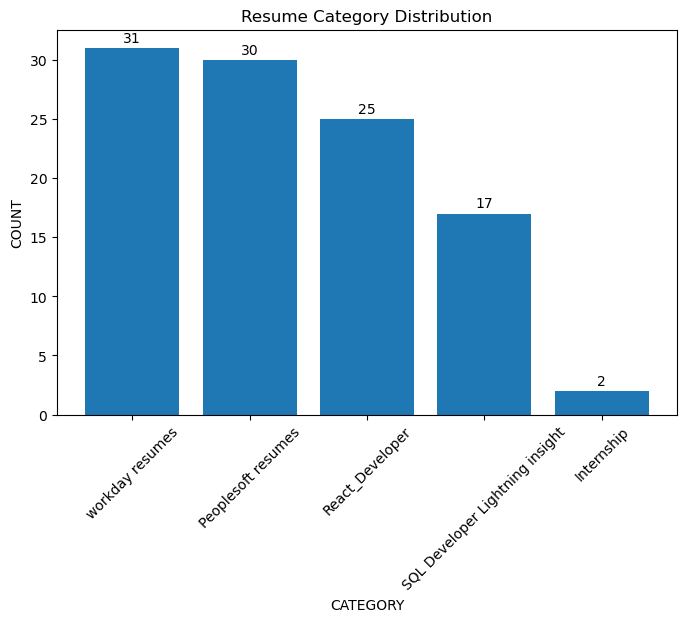

In [4]:
import matplotlib.pyplot as plt

category_counts = df["category"].value_counts()

plt.figure(figsize=(8,5))
bars = plt.bar(category_counts.index, category_counts.values)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center')

plt.title("Resume Category Distribution")
plt.xlabel("CATEGORY")
plt.ylabel("COUNT")
plt.xticks(rotation=45)
plt.show()

***TEXT CLEANING***

In [5]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z ]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_resume"] = df["resume"].apply(clean_text)

# Remove empty rows
df = df[df["clean_resume"].str.strip() != ""]

***Resume Length Distribution***

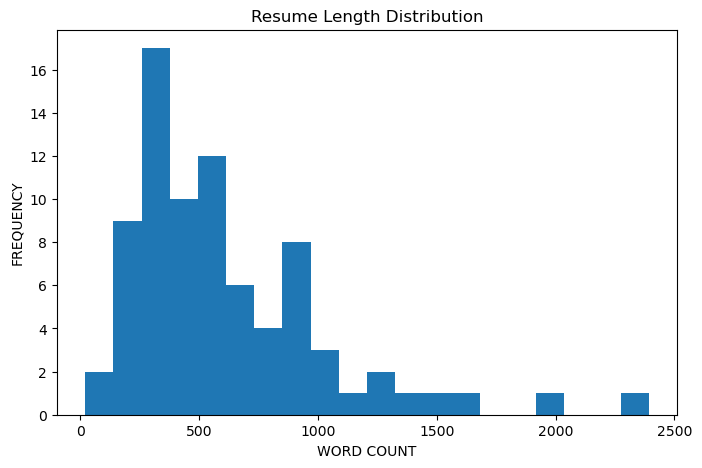

In [6]:
df["resume_length"] = df["clean_resume"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
plt.hist(df["resume_length"], bins=20)
plt.title("Resume Length Distribution")
plt.xlabel("WORD COUNT")
plt.ylabel("FREQUENCY")
plt.show()

***Category vs Length***

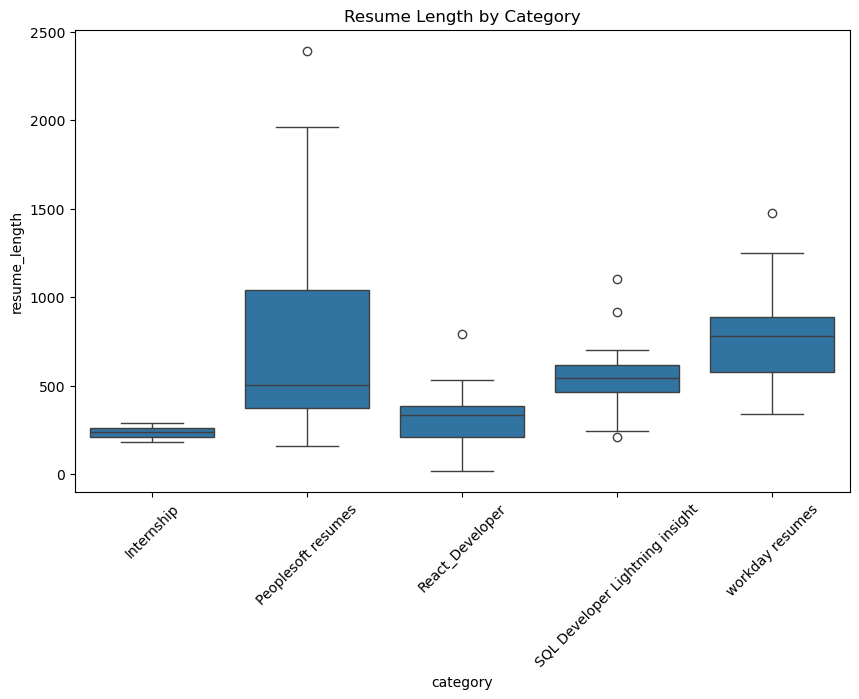

In [7]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(x="category", y="resume_length", data=df)

plt.xticks(rotation=45)
plt.title("Resume Length by Category")
plt.show()

***Word Cloud***

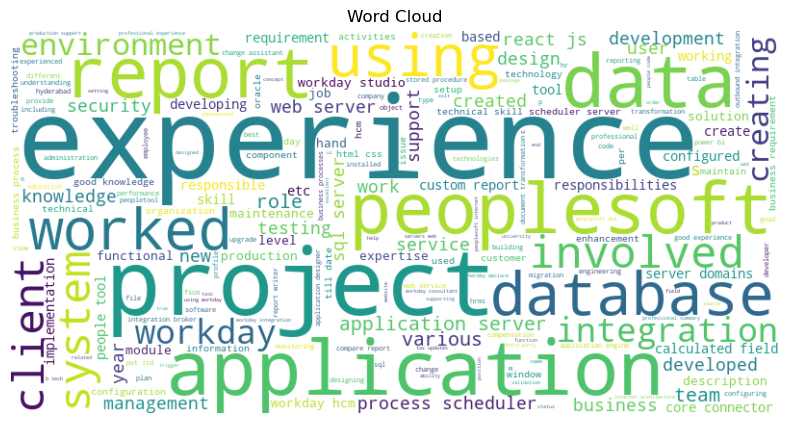

In [8]:
from wordcloud import WordCloud

text = " ".join(df["clean_resume"])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud")
plt.show()

# Feature Engineering

***TF-IDF***

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["clean_resume"])
y = df["category"]

***Train - Test split***

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Building

In [11]:
# MULTINOMIAL NAIVE BAYES
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [12]:
# Prediction
y_pred = model.predict(X_test)

# Model Evaluation

In [13]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8125
                                 precision    recall  f1-score   support

                     Internship       0.00      0.00      0.00         1
             Peoplesoft resumes       1.00      1.00      1.00         4
                React_Developer       1.00      1.00      1.00         6
SQL Developer Lightning insight       0.00      0.00      0.00         2
                workday resumes       0.50      1.00      0.67         3

                       accuracy                           0.81        16
                      macro avg       0.50      0.60      0.53        16
                   weighted avg       0.72      0.81      0.75        16



C:\Users\MI\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\MI\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\MI\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Confusion Matrix

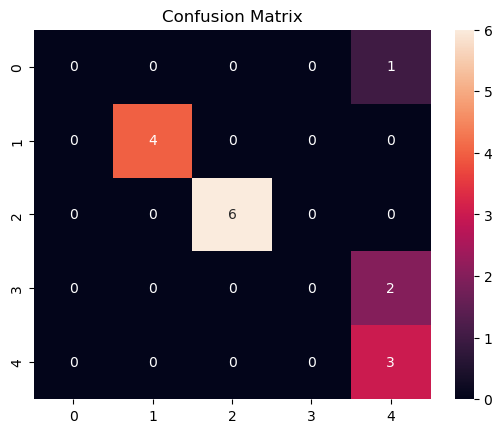

In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# Saving the Model

In [15]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump((model, tfidf), f)

***Streamlit Open***

In [19]:
import os
import time
import webbrowser

# ✅ FULL PATH TO YOUR RESUME PROJECT APP
app_path = r"C:\Users\MI\Desktop\Resume_Classification\app.py"

os.system(f'start cmd /k streamlit run "{app_path}"')

time.sleep(5)

webbrowser.open("http://localhost:8501")

True